In [ ]:
#High-Level Outline of the Transformer Model Code
#Data Preparation:
#Tokenization and vocabulary building (size: 2000 words).
#Padding and truncation of sentences to a maximum length of 70 words.
#Building the Transformer Model:
#Define the encoder and decoder layers.
#Implement multi-head attention, position-wise feedforward networks, and positional encoding.
#Combine these components to build the full Transformer model.
#Training the Model:
#Loss function (e.g., cross-entropy loss).
#Optimizer and learning rate scheduling.
#Training loop with evaluation on a validation set.
#Translation and Evaluation:
#Function for translating input sentences.
#Calculate BLEU score or another translation quality metric.
#Comparison with the Encoder-Decoder Model:
#Translate the same sentences as in Problem 1.
#Compare the BLEU scores of the two models.


In [1]:
!pip install tensorflow

In [20]:
import pandas as pd

In [21]:
#Step 1: Import Necessary Libraries

import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Attention
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Embedding, Concatenate, Attention
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.layers import LayerNormalization, Dropout, Dense, Embedding, Layer

In [22]:
# Load the dataset
file_path = '/Users/shiveshrajsahu/Desktop/Cs767/cs767A1_SAHU_SHIVESH_HW10/hin.csv'
dataset = pd.read_csv(file_path)

# Display the first few lines of the dataset to understand its structure
dataset.head()


,Wow!,वाह!,CC-BY 2.0 (France) Attribution: tatoeba.org #52027 (Zifre) & #6179147 (fastrizwaan)
0,Duck!,झुको!,CC-BY 2.0 (France) Attribution: tatoeba.org #2...
1,Duck!,बतख़!,CC-BY 2.0 (France) Attribution: tatoeba.org #2...
2,Help!,बचाओ!,CC-BY 2.0 (France) Attribution: tatoeba.org #4...
3,Jump.,उछलो.,CC-BY 2.0 (France) Attribution: tatoeba.org #6...
4,Jump.,कूदो.,CC-BY 2.0 (France) Attribution: tatoeba.org #6...


In [23]:
# Load and examine the first few lines of the dataset to understand its structure
#file_path = '/Users/shiveshrajsahu/Desktop/Cs767/cs767A1_SAHU_SHIVESH_HW10/hin.csv'

# Reading the first few lines of the file
with open(file_path, 'r', encoding='utf-8') as file:
    first_lines = [next(file) for _ in range(5)]

first_lines

['Wow!,वाह!,CC-BY 2.0 (France) Attribution: tatoeba.org #52027 (Zifre) & #6179147 (fastrizwaan)\n',
 'Duck!,झुको!,CC-BY 2.0 (France) Attribution: tatoeba.org #280158 (CM) & #6179041 (fastrizwaan)\n',
 'Duck!,बतख़!,CC-BY 2.0 (France) Attribution: tatoeba.org #280158 (CM) & #6179042 (fastrizwaan)\n',
 'Help!,बचाओ!,CC-BY 2.0 (France) Attribution: tatoeba.org #435084 (lukaszpp) & #459377 (minshirui)\n',
 'Jump.,उछलो.,CC-BY 2.0 (France) Attribution: tatoeba.org #631038 (Shishir) & #6179121 (fastrizwaan)\n']

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
import re
import random

# Load the dataset
df = pd.read_csv(file_path, header=None, usecols=[0, 1], names=['English', 'Hindi'])

# Data cleaning function
def clean_sentence(sentence):
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,¿])", r" \1 ", sentence)  # creating a space between words and punctuation
    sentence = re.sub(r'[" "]+', " ", sentence)         # replacing multiple spaces with a single space
    sentence = re.sub(r"[^a-zA-Z?.!,¿]+", " ", sentence)  # removing all characters except a-z and punctuation
    return sentence.strip()

# Applying cleaning function to both English and Hindi sentences
df['English'] = df['English'].apply(clean_sentence)
df['Hindi'] = df['Hindi'].apply(lambda x: x.strip().lower())

# Splitting the dataset
train, test = train_test_split(df, test_size=0.15, random_state=42)
train, val = train_test_split(train, test_size=45/85, random_state=42)  # 45% of 85% is approximately 53% of the original

# Showing the sizes of each dataset and a few samples
train_size = len(train)
val_size = len(val)
test_size = len(test)

train.head(), val.head(), test.head(), (train_size, val_size, test_size)


(                                      English  \
 1372            she was robbed of her purse .   
 2217   i want to know why tom is doing this .   
 792                  i seem to have a fever .   
 2489  he is always here between and o clock .   
 894                 i really like city life .   
 
                                              Hindi  
 1372                 उसका पर्स उससे चुरा लिया गया।  
 2217     मुझे यह बताओ, कि टॉम ऐसा कर क्यों रहा है।  
 792                       मुझे बुखार जैसा लगता है।  
 2489  वह हमेशा यहाँ पाँच से छः बजे के बीच होता है।  
 894                  मुझे शहर की ज़िन्दगी पसंद है।  ,
                                         English  \
 293                          it s april first .   
 2427  we should try to understand one another .   
 759                     you reap what you sow .   
 86                                he stood up .   
 2353   she is living in some village in india .   
 
                                            Hindi  
 293   

In [30]:
# Save the split data to files
train.to_csv('train_set.csv', index=False)
val.to_csv('validation_set.csv', index=False)  # Corrected the variable name here
test.to_csv('test_set.csv', index=False)


In [55]:
text_file = '/Users/shiveshrajsahu/Desktop/Cs767/cs767A1_SAHU_SHIVESH_HW10/hin-eng/hin.txt'

In [56]:
with open(text_file, encoding="utf8") as f:
    lines = f.read().split("\n")[:-1]

text_pairs = []
for line in lines:
    line = line.replace("¡", "").replace("¿", "")
    parts = line.split("\t")
    if len(parts) >= 2:
        eng, ita = parts[0], parts[1]  
        text_pairs.append([eng, ita])
    else:
       
        print(f"Skipping line: {line}")

In [57]:
np.random.seed(42)  
np.random.shuffle(text_pairs)
sentences_en, sentences_ita = zip(*text_pairs)  

In [58]:
#Printing the first 10 lines of our data set

In [59]:
for i in range(10):
    print(sentences_en[i], "=>", sentences_ita[i])

It's getting dark. You'd better go home. => दिन ढल रहा है। तुम्हें घर जाना चाहिए।
That's too small to fit on your head. => वह तुम्हारे सर के लिए बहुत छोटा है।
Sickness prevented him from going out. => वह बीमारी की वजह से बाहर नहीं जा सका।
You should conform to the rules. => तुम्हें नियमों का पालन करना चाहिए।
I told Tom what he should do, but he didn't do it. => मैंने टॉम को बताया उसे क्या करना चाहिए पर उसने वैसा नहीं किया।
I have lots of work to clear up by the weekend. => मुझे इस हफ़्ते बहुत सारा काम कर के खतम करना है।
These dogs are big. => ये कुत्ते बड़े हैं।
The Japanese eat rice at least once a day. => जापानी दिन में कम-से-कम एक बार चावल खाते है।
Who'd want to kill you? => तुम्हें कौन मारना चाहेगा?
The food's not ready yet. => खाना अभी तक तैयार नहीं हुआ है।


In [60]:
vocab_size = 2000
max_length = 70
text_vec_layer_en = tf.keras.layers.TextVectorization(
    vocab_size, output_sequence_length=max_length)
text_vec_layer_ita = tf.keras.layers.TextVectorization(
    vocab_size, output_sequence_length=max_length)
text_vec_layer_en.adapt(sentences_en)
text_vec_layer_ita.adapt([f"startofseq {s} endofseq" for s in sentences_ita])

In [61]:
num_train_samples = int(0.5 * len(sentences_en)) # 50 %
num_test_samples = int(0.15 * len(sentences_en)) # 15 %
num_val_samples = len(sentences_en) - num_train_samples - num_test_samples # 35 %

In [62]:
X_train = tf.constant(sentences_en[:num_train_samples])
X_valid = tf.constant(sentences_en[num_train_samples : num_train_samples + num_val_samples])


In [63]:
X_train_dec = tf.constant([f"startofseq {s}" for s in sentences_ita[:num_train_samples]])
X_valid_dec = tf.constant([f"startofseq {s}" for s in sentences_ita[num_train_samples : num_train_samples + num_val_samples]])
X_test_dec = tf.constant([f"startofseq {s}" for s in sentences_ita[num_train_samples + num_val_samples :]])

In [64]:
Y_train = text_vec_layer_ita([f"{s} endofseq" for s in sentences_ita[:num_train_samples]])
Y_valid = text_vec_layer_ita([f"{s} endofseq" for s in sentences_ita[num_train_samples : num_train_samples + num_val_samples]])


In [65]:
X_test =  sentences_en[num_train_samples + num_val_samples :]

In [66]:
Y_test =  sentences_ita[num_train_samples + num_val_samples :]

In [67]:
tf.random.set_seed(42)  
encoder_inputs = tf.keras.layers.Input(shape=[], dtype=tf.string)
decoder_inputs = tf.keras.layers.Input(shape=[], dtype=tf.string)

In [68]:
embed_size = 128
encoder_input_ids = text_vec_layer_en(encoder_inputs)
decoder_input_ids = text_vec_layer_ita(decoder_inputs)
encoder_embedding_layer = tf.keras.layers.Embedding(vocab_size, embed_size,
                                                    mask_zero=True)
decoder_embedding_layer = tf.keras.layers.Embedding(vocab_size, embed_size,
                                                    mask_zero=True)
encoder_embeddings = encoder_embedding_layer(encoder_input_ids)
decoder_embeddings = decoder_embedding_layer(decoder_input_ids)

In [69]:
max_length = 70  
embed_size = 128
tf.random.set_seed(42)  
pos_embed_layer = tf.keras.layers.Embedding(max_length, embed_size)
batch_max_len_enc = tf.shape(encoder_embeddings)[1]
encoder_in = encoder_embeddings + pos_embed_layer(tf.range(batch_max_len_enc))
batch_max_len_dec = tf.shape(decoder_embeddings)[1]
decoder_in = decoder_embeddings + pos_embed_layer(tf.range(batch_max_len_dec))

In [70]:
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_length, embed_size, dtype=tf.float32, **kwargs):
        super().__init__(dtype=dtype, **kwargs)
        assert embed_size % 2 == 0, "embed_size must be even"
        p, i = np.meshgrid(np.arange(max_length),
                           2 * np.arange(embed_size // 2))
        pos_emb = np.empty((1, max_length, embed_size))
        pos_emb[0, :, ::2] = np.sin(p / 10_000 ** (i / embed_size)).T
        pos_emb[0, :, 1::2] = np.cos(p / 10_000 ** (i / embed_size)).T
        self.pos_encodings = tf.constant(pos_emb.astype(self.dtype))
        self.supports_masking = True

    def call(self, inputs):
        batch_max_length = tf.shape(inputs)[1]
        return inputs + self.pos_encodings[:, :batch_max_length]

In [71]:
pos_embed_layer = PositionalEncoding(max_length, embed_size)
encoder_in = pos_embed_layer(encoder_embeddings)
decoder_in = pos_embed_layer(decoder_embeddings)

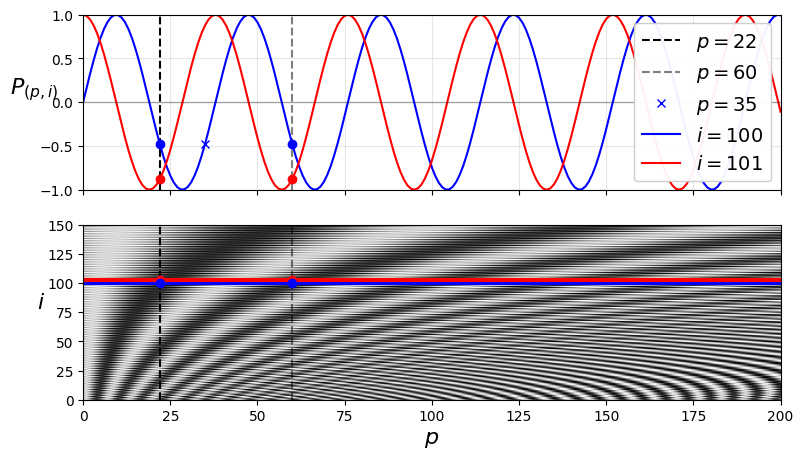

In [74]:
import matplotlib.pyplot as plt
figure_max_length = 201
figure_embed_size = 512
pos_emb = PositionalEncoding(figure_max_length, figure_embed_size)
zeros = np.zeros((1, figure_max_length, figure_embed_size), np.float32)
P = pos_emb(zeros)[0].numpy()
i1, i2, crop_i = 100, 101, 150
p1, p2, p3 = 22, 60, 35
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(9, 5))
ax1.plot([p1, p1], [-1, 1], "k--", label="$p = {}$".format(p1))
ax1.plot([p2, p2], [-1, 1], "k--", label="$p = {}$".format(p2), alpha=0.5)
ax1.plot(p3, P[p3, i1], "bx", label="$p = {}$".format(p3))
ax1.plot(P[:,i1], "b-", label="$i = {}$".format(i1))
ax1.plot(P[:,i2], "r-", label="$i = {}$".format(i2))
ax1.plot([p1, p2], [P[p1, i1], P[p2, i1]], "bo")
ax1.plot([p1, p2], [P[p1, i2], P[p2, i2]], "ro")
ax1.legend(loc="center right", fontsize=14, framealpha=0.95)
ax1.set_ylabel("$P_{(p,i)}$", rotation=0, fontsize=16)
ax1.grid(True, alpha=0.3)
ax1.hlines(0, 0, figure_max_length - 1, color="k", linewidth=1, alpha=0.3)
ax1.axis([0, figure_max_length - 1, -1, 1])
ax2.imshow(P.T[:crop_i], cmap="gray", interpolation="bilinear", aspect="auto")
ax2.hlines(i1, 0, figure_max_length - 1, color="b", linewidth=3)
cheat = 2  # need to raise the red line a bit, or else it hides the blue one
ax2.hlines(i2+cheat, 0, figure_max_length - 1, color="r", linewidth=3)
ax2.plot([p1, p1], [0, crop_i], "k--")
ax2.plot([p2, p2], [0, crop_i], "k--", alpha=0.5)
ax2.plot([p1, p2], [i2+cheat, i2+cheat], "ro")
ax2.plot([p1, p2], [i1, i1], "bo")
ax2.axis([0, figure_max_length - 1, 0, crop_i])
ax2.set_xlabel("$p$", fontsize=16)
ax2.set_ylabel("$i$", rotation=0, fontsize=16)
plt.show()

In [75]:
N = 2  
num_heads = 8
dropout_rate = 0.1
n_units = 128 
encoder_pad_mask = tf.math.not_equal(encoder_input_ids, 0)[:, tf.newaxis]
Z = encoder_in
for _ in range(N):
    skip = Z
    attn_layer = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_size, dropout=dropout_rate)
    Z = attn_layer(Z, value=Z, attention_mask=encoder_pad_mask)
    Z = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([Z, skip]))
    skip = Z
    Z = tf.keras.layers.Dense(n_units, activation="relu")(Z)
    Z = tf.keras.layers.Dense(embed_size)(Z)
    Z = tf.keras.layers.Dropout(dropout_rate)(Z)
    Z = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([Z, skip]))

In [76]:
decoder_pad_mask = tf.math.not_equal(decoder_input_ids, 0)[:, tf.newaxis]
causal_mask = tf.linalg.band_part(  # creates a lower triangular matrix
    tf.ones((batch_max_len_dec, batch_max_len_dec), tf.bool), -1, 0)

In [77]:
encoder_outputs = Z  # let's save the encoder's final outputs
Z = decoder_in  # the decoder starts with its own inputs
for _ in range(N):
    skip = Z
    attn_layer = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_size, dropout=dropout_rate)
    Z = attn_layer(Z, value=Z, attention_mask=causal_mask & decoder_pad_mask)
    Z = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([Z, skip]))
    skip = Z
    attn_layer = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_size, dropout=dropout_rate)
    Z = attn_layer(Z, value=encoder_outputs, attention_mask=encoder_pad_mask)
    Z = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([Z, skip]))
    skip = Z
    Z = tf.keras.layers.Dense(n_units, activation="relu")(Z)
    Z = tf.keras.layers.Dense(embed_size)(Z)
    Z = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([Z, skip]))

In [78]:
# run with 2 epohs
Y_proba = tf.keras.layers.Dense(vocab_size, activation="softmax")(Z)
model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs],
                       outputs=[Y_proba])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
model.fit((X_train, X_train_dec), Y_train, epochs=2,
          validation_data=((X_valid, X_valid_dec), Y_valid))

Epoch 1/2
47/47 [==============================] - 22s 418ms/step - loss: 6.0676 - accuracy: 0.1325 - val_loss: 5.6084 - val_accuracy: 0.1486
Epoch 2/2
47/47 [==============================] - 19s 413ms/step - loss: 5.3931 - accuracy: 0.1554 - val_loss: 5.4182 - val_accuracy: 0.1583


In [79]:
#now run with 20 epohs
Y_proba = tf.keras.layers.Dense(vocab_size, activation="softmax")(Z)
model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs],
                       outputs=[Y_proba])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
model.fit((X_train, X_train_dec), Y_train, epochs=20,
          validation_data=((X_valid, X_valid_dec), Y_valid))

Epoch 1/20
47/47 [==============================] - 22s 420ms/step - loss: 5.9846 - accuracy: 0.1420 - val_loss: 5.4174 - val_accuracy: 0.1636
Epoch 2/20
47/47 [==============================] - 19s 415ms/step - loss: 5.1924 - accuracy: 0.1702 - val_loss: 5.2477 - val_accuracy: 0.1739
Epoch 3/20
47/47 [==============================] - 20s 418ms/step - loss: 4.9971 - accuracy: 0.1772 - val_loss: 5.2520 - val_accuracy: 0.1728
Epoch 4/20
47/47 [==============================] - 20s 417ms/step - loss: 4.8858 - accuracy: 0.1801 - val_loss: 5.1973 - val_accuracy: 0.1749
Epoch 5/20
47/47 [==============================] - 19s 412ms/step - loss: 4.7906 - accuracy: 0.1840 - val_loss: 5.2281 - val_accuracy: 0.1744
Epoch 6/20
47/47 [==============================] - 19s 408ms/step - loss: 4.6895 - accuracy: 0.1893 - val_loss: 5.2355 - val_accuracy: 0.1763
Epoch 7/20
47/47 [==============================] - 19s 404ms/step - loss: 4.6328 - accuracy: 0.1885 - val_loss: 5.2138 - val_accuracy: 0.1770

In [80]:
def translate(sentence_en):
    translation = ""
    for word_idx in range(70):
        X = np.array([sentence_en])  # encoder input
        X_dec = np.array(["startofseq " + translation])  # decoder input
        y_proba = model.predict((X, X_dec))[0, word_idx]  # last token's probas
        predicted_word_id = np.argmax(y_proba)
        predicted_word = text_vec_layer_ita.get_vocabulary()[predicted_word_id]
        if predicted_word == "endofseq":
            break
        translation += " " + predicted_word
    return translation.strip()

In [81]:
#testing 
translate("sunrise")

1/1 [==============================] - 0s 16ms/step


'[UNK]'

In [82]:
#testing 
translate("sunset")

1/1 [==============================] - 0s 16ms/step


'[UNK]'

In [83]:
def translate_batch():
    random.seed(42)
    sentence_index = [random.randrange(0, len(X_test) - 1) for _ in range(10)]
    eng_sentences = []
    tr_sentences = []
    
    for idx in sentence_index:
        translation = translate(X_test[idx])
        tr_sentences.append(translation)
        eng_sentences.append(X_test[idx])
       
    return eng_sentences, tr_sentences 

In [84]:
english_sentences, translated_sentences = translate_batch()

1/1 [==============================] - 0s 17ms/step


In [85]:
for eng_sent, tr_sent in zip(english_sentences, translated_sentences):
    print(f"Sentence in english: {eng_sent}")
    print(f"Sentence translated by model: {tr_sent}")
    print("-" * 50)

Sentence in english: I don't think that it will rain tomorrow.
Sentence translated by model: मुझे [UNK] में [UNK] कि वह मन है।
--------------------------------------------------
Sentence in english: The two languages have a lot in common.
Sentence translated by model: मुझे [UNK] में [UNK] कि वह मन है।
--------------------------------------------------
Sentence in english: I'm too tired to walk.
Sentence translated by model: मुझे [UNK] है।
--------------------------------------------------
Sentence in english: This is the very book that I wanted to read.
Sentence translated by model: मुझे नहीं कि मुझे [UNK]
--------------------------------------------------
Sentence in english: Tom didn't have any hair.
Sentence translated by model: मुझे [UNK] है।
--------------------------------------------------
Sentence in english: Your dog is very big.
Sentence translated by model: यह मेरी [UNK] है।
--------------------------------------------------
Sentence in english: When did you get married?
Sen

In [86]:
!pip install sacrebleu

In [87]:
!pip install datasets

In [88]:
X_blue = X_test[1000:1500]
Y_blue = Y_test[1000:1500]

In [89]:
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import corpus_bleu

In [90]:
tr_sentences = []
eng_sentences = []
blue_score = []
orig_sentences = []
for idx in range(len(X_blue)):
    translation = translate(X_blue[idx])
    orig = Y_blue[idx]
    orig_sentences.append(orig)
    blue_sc = sentence_bleu([orig.split()], translation.split(), weights = (0.5, 0.5))
    blue_score.append(blue_sc)
    tr_sentences.append(translation)
    eng_sentences.append(X_blue[idx])

In [91]:
for i in range(len(tr_sentences)):
    print(f"Original sentence: {orig_sentences[i]}")
    print(f"Sentence translated by model: {tr_sentences[i]}")
    print(f"Bleu score: {blue_score[i]}")
    print("-" * 50)

In [93]:
import sacrebleu

def translate_batch_and_calculate_bleu():
    random.seed(42)
    sentence_index = [random.randrange(0, len(X_test) - 1) for _ in range(10)] # Or a different number of sentences
    eng_sentences = []
    tr_sentences = []
    bleu_scores = []

    for idx in sentence_index:
        translation = translate(X_test[idx])
        tr_sentences.append(translation)
        eng_sentences.append(X_test[idx])

        # Calculate BLEU score
        ref = [Y_test[idx]]
        bleu_score = sacrebleu.corpus_bleu([translation], [ref]).score
        bleu_scores.append(bleu_score)

    return eng_sentences, tr_sentences, bleu_scores

english_sentences, translated_sentences, bleu_scores = translate_batch_and_calculate_bleu()


1/1 [==============================] - 0s 17ms/step


In [94]:
# Print results
for eng_sent, tr_sent, bleu in zip(english_sentences, translated_sentences, bleu_scores):
    print(f"Sentence in English: {eng_sent}")
    print(f"Sentence translated by model: {tr_sent}")
    print(f"BLEU score: {bleu}")
    print("-" * 50)

# Calculate average BLEU score
average_bleu_score = sum(bleu_scores) / len(bleu_scores)
print(f"Average BLEU score: {average_bleu_score}")

Sentence in English: I don't think that it will rain tomorrow.
Sentence translated by model: मुझे [UNK] में [UNK] कि वह मन है।
BLEU score: 3.3864985683445354
--------------------------------------------------
Sentence in English: The two languages have a lot in common.
Sentence translated by model: मुझे [UNK] में [UNK] कि वह मन है।
BLEU score: 3.3864985683445354
--------------------------------------------------
Sentence in English: I'm too tired to walk.
Sentence translated by model: मुझे [UNK] है।
BLEU score: 0.0
--------------------------------------------------
Sentence in English: This is the very book that I wanted to read.
Sentence translated by model: मुझे नहीं कि मुझे [UNK]
BLEU score: 0.0
--------------------------------------------------
Sentence in English: Tom didn't have any hair.
Sentence translated by model: मुझे [UNK] है।
BLEU score: 0.0
--------------------------------------------------
Sentence in English: Your dog is very big.
Sentence translated by model: यह मेरी [

In [96]:
#Average BLEU score: 2.3006392910444022

In [97]:
#conclusions:

# observe that when using transformer model our average Bleu score 
#slightly decreased from 4.978174524177378(from problem 1) to 2.3006392910444022(from problem 2)

#This may be due to the fact that transformers show their full benefits when working with 
#larger datasets and tasks that require understanding of long-term context.